# 01 · Análisis Exploratorio de Datos

**Objetivo:** Entender el dataset HAM10000 antes de modelar.

**Datos de entrada:** `../data/raw/HAM10000_metadata.csv`, `../data/raw/hnmist_28_28_RGB.csv`

**Resultado esperado:** Comprensión de la distribución de clases, valores nulos, tipos de variables y aspecto visual de las imágenes.

El objetivo de este trabajo consiste en resolver un problema del mundo real empleando para 
ello técnicas vistas durante las sesiones de dicho módulo. En concreto, se trabajará en 
predecir la condición médica sufrida por una cohorte de pacientes a partir de las diferentes 
fuentes de información disponibles (imágenes y datos tabulares). 

El primer paso sería crear un diccionario de columnas:
| Columna      | Descripción                                                             |
| ------------ | ----------------------------------------------------------------------- |
| lesion_id    | Identificador único de la lesión                                        |
| image_id     | Identificador único de la imagen asociada a la lesión                   |
| dx           | Diagnóstico de la lesión (código de enfermedad, ej. nv, mel, bkl, etc.) |
| dx_type      | Tipo de diagnóstico (ej. histopatológico, clínico, confocal)            |
| age          | Edad del paciente en años                                               |
| sex          | Sexo del paciente (male/female/unknown)                                 |
| localization | Localización de la lesión en el cuerpo                                  |
| dataset      | Conjunto de datos de origen de la imagen/lesión                         |

Tras observar el dataset, también hacemos una pequeña observación de las enfermedades estudiadas, para lo cual creamos el siguiente "diccionario", añadiendo el número de casos en cada uno


| Enfermedad                           | Descripción                                           | Código | Nº de casos |
|-------------------------------------|------------------------------------------------------|--------|------------|
| Actinic keratoses y carcinoma de células escamosas | Tipo de cáncer de piel                                | akiec  | 327        |
| Nevus melanocítico                   | Lesión benigna común                                  | nv     | 6705       |
| Melanoma                             | Tipo de cáncer de piel agresivo                       | mel    | 1113       |
| Lesiones benignas de queratosis      | Incluyen lentigo solar y queratosis seborreica       | bkl    | 1099       |
| Dermatofibroma                        | Lesión benigna del tejido fibroso                     | df     | 115        |
| Vasculares                            | Lesiones vasculares como hemangiomas                 | vasc   | 142        |
| Lesión de células basales             | Un tipo de cáncer de piel menos agresivo que el melanoma | bcc    | 514        |


In [ ]:
import os

# Ver la estructura de la carpeta data (relativa al notebook)
data_path = "../data"
for root, dirs, files in os.walk(data_path):
    level = root.replace(data_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

In [7]:
#Para comenzar, carguemos los datos tabulares utilizando pandas:
import pandas as pd

df = pd.read_csv(r"../data/raw/HAM10000_metadata.csv")
print(df.head())
df.info()
df.head()
df.describe(include="all")
df.isna().sum()
print(df['dx'].value_counts())  # Para ver cuántas muestras hay de cada enfermedad

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
dx
nv       6705
mel      1113
bkl      1099
bcc 

| **Columna**    | **Tipo** | **Descripción**                                                                                                                                             |
| -------------- | -------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `age`          | `int`    | Edad del paciente (valores imputados con la mediana y redondeados).                                                                                         |
| `sex`          | `object` | Sexo del paciente. Puede tomar los valores: `male`, `female` o `unknown`. *(Pendiente de codificar a numérico si el modelo lo requiere)*                    |
| `localization` | `object` | Localización anatómica de la lesión (por ejemplo, `back`, `trunk`, `lower extremity`, etc.). *(Pendiente de codificar a numérico si el modelo lo requiere)* |
| `akiec`     | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Actinic keratoses / intraepithelial carcinoma (akiec)**.                                            |
| `bcc`       | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Basal cell carcinoma (bcc)**.                                                                       |
| `bkl`       | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Benign keratosis-like lesions (bkl)**.                                                              |
| `df`        | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Dermatofibroma (df)**.                                                                              |
| `mel`       | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Melanoma (mel)**.                                                                                   |
| `nv`        | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Melanocytic nevi (nv)**.                                                                            |
| `vasc`      | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Vascular lesions (vasc)**.                                                                          |


## Muestra visual de imágenes

Comprobamos que las imágenes se carguen correctamente y tienen el aspecto esperado (28×28 píxeles RGB).

Clases: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


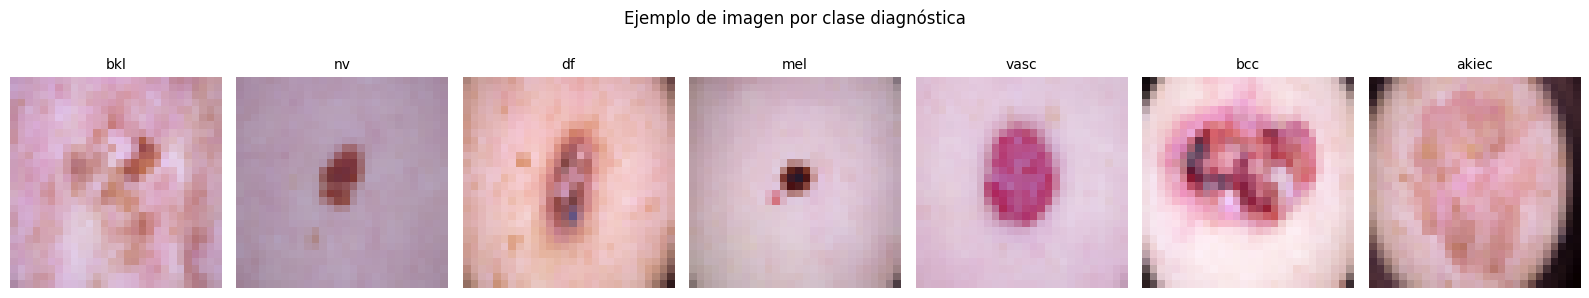

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargamos los datos necesarios para la visualización
df_images   = pd.read_csv(r"../data/raw/hnmist_28_28_RGB.csv")
df_metadata = pd.read_csv(r"../data/raw/HAM10000_metadata.csv")

clases = df_metadata['dx'].unique()
print(f"Clases: {clases}")

# Mostramos una imagen de ejemplo por cada clase
fig, axes = plt.subplots(1, len(clases), figsize=(16, 3))
for ax, clase in zip(axes, clases):
    idx = df_metadata[df_metadata['dx'] == clase].index[0]
    img = df_images.iloc[idx].values.reshape(28, 28, 3).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(clase, fontsize=10)
    ax.axis('off')

plt.suptitle('Ejemplo de imagen por clase diagnóstica', y=1.02)
plt.tight_layout()
plt.show()

## Conclusiones del EDA

- El dataset tiene **10.015 muestras** de 7 clases de lesiones cutáneas.
- **Desbalanceo de clases notable**: la clase `nv` (nevus) representa ~67% de los datos.
- La columna `age` tiene valores nulos que se imputarán con la mediana.
- Las imágenes están preprocesadas a 28×28 píxeles RGB y almacenadas como CSV.
- Estas observaciones justifican el uso de `stratify` en el split y la imputación por mediana.